In [34]:
!pip install simpy

```markdown
# Message Queue Processing Simulation with SimPy

This notebook models a discrete-event simulation for a queue of **200,000 messages** and **20 threads/workers** (default configuration).

Each worker pulls one message, processes it, and then takes the next one. Processing time for a single message is defined by a distribution with the following parameters:

- 50th percentile (Median): **15.0 seconds**
- 95th percentile: **45.0 seconds**

Resulting metrics calculated include:

- Throughput (messages per second and minute) for the whole system;
- Individual worker throughput;
- Total time elapsed to process all messages;
- Processing speed charts over time.
```

In [35]:
import math
from dataclasses import dataclass

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
import simpy

sns.set_theme(style="whitegrid")
pd.set_option("display.float_format", "{:.3f}".format)

```markdown
## Simulation Parameters

A log-normal distribution is used for processing time. This is suitable for such tasks because time is always positive, and the long right tail naturally describes occasional slow processing tasks.

Distribution parameters are calculated to match the specified percentiles:

- `median = exp(mu) = 15.0`
- `p95 = exp(mu + sigma * z95) = 45.0`, where `z95 ≈ 1.64485`
```

In [36]:
@dataclass(frozen=True)
class SimulationConfig:
    messages: int = 200_000
    workers: int = 1
    median_seconds: float = 15.0
    p95_seconds: float = 45.0
    random_seed: int = 42


config = SimulationConfig()

Z95 = 1.6448536269514722
lognormal_mu = math.log(config.median_seconds)
lognormal_sigma = math.log(config.p95_seconds / config.median_seconds) / Z95

print(f"mu: {lognormal_mu:.4f}")
print(f"sigma: {lognormal_sigma:.4f}")
print(f"theoretical median: {math.exp(lognormal_mu):.3f} sec")
print(f"theoretical p95: {math.exp(lognormal_mu + lognormal_sigma * Z95):.3f} sec")
print(f"theoretical mean: {math.exp(lognormal_mu + 0.5 * lognormal_sigma**2):.3f} sec")

mu: 2.7081
sigma: 0.6679
theoretical median: 15.000 sec
theoretical p95: 45.000 sec
theoretical mean: 18.748 sec


```markdown
## SimPy Model

The model uses `simpy.Store` as a message queue. A worker waits for a message, records the start time, executes `env.timeout(processing_time)`, and then records completion.
```

In [23]:
def sample_processing_time(rng: np.random.Generator) -> float:
    return float(rng.lognormal(mean=lognormal_mu, sigma=lognormal_sigma))


def worker(env: simpy.Environment, worker_id: int, queue: simpy.Store, rng: np.random.Generator, records: list[dict]):
    while True:
        message_id = yield queue.get()
        if message_id is None:
            break

        start_time = env.now
        duration = sample_processing_time(rng)
        yield env.timeout(duration)
        finish_time = env.now

        records.append(
            {
                "message_id": message_id,
                "worker_id": worker_id,
                "start_time": start_time,
                "finish_time": finish_time,
                "duration": duration,
            }
        )


def run_simulation(config: SimulationConfig) -> pd.DataFrame:
    env = simpy.Environment()
    queue = simpy.Store(env)
    rng = np.random.default_rng(config.random_seed)
    records: list[dict] = []

    # Для 200k сообщений список в памяти небольшой, а Store делает модель явной и читаемой.
    queue.items = list(range(config.messages)) + [None] * config.workers

    for worker_id in range(config.workers):
        env.process(worker(env, worker_id, queue, rng, records))

    env.run()

    result = pd.DataFrame.from_records(records)
    return result.sort_values("finish_time", ignore_index=True)


results = run_simulation(config)
results.head()

,message_id,worker_id,start_time,finish_time,duration
0,0,0,0.000,18.386,18.386
1,1,0,18.386,25.875,7.489
2,2,0,25.875,50.636,24.761
3,3,0,50.636,78.750,28.114
4,4,0,78.750,82.825,4.075


```markdown
## Verification of Processing Time Distribution
```

In [24]:
duration_stats = results["duration"].describe(percentiles=[0.5, 0.95, 0.99]).to_frame("seconds")
duration_stats

,seconds
count,200000.000
mean,18.776
std,14.289
min,0.558
50%,14.970
95%,45.152
99%,71.800
max,425.144


```markdown
## Final Throughput and Total Processing Time
```

In [25]:
total_messages = len(results)
total_time_seconds = results["finish_time"].max()
total_time_minutes = total_time_seconds / 60
total_time_hours = total_time_seconds / 3600

overall_messages_per_second = total_messages / total_time_seconds
overall_messages_per_minute = overall_messages_per_second * 60

summary = pd.DataFrame(
    [
        {"metric": "messages", "value": total_messages},
        {"metric": "total_time_seconds", "value": total_time_seconds},
        {"metric": "total_time_minutes", "value": total_time_minutes},
        {"metric": "total_time_hours", "value": total_time_hours},
        {"metric": "all_workers_messages_per_second", "value": overall_messages_per_second},
        {"metric": "all_workers_messages_per_minute", "value": overall_messages_per_minute},
    ]
)

summary

,metric,value
0,messages,200000.000
1,total_time_seconds,3755185.550
2,total_time_minutes,62586.426
3,total_time_hours,1043.107
4,all_workers_messages_per_second,0.053
5,all_workers_messages_per_minute,3.196


```markdown
## Individual Worker Throughput

`messages_per_second_total_window` calculates the average speed of a worker over the entire simulation interval. This is useful for comparison with the total system speed.

`messages_per_second_active_window` calculates the speed only during the active time of a specific worker, from their first start to their last finish.
```

In [26]:
worker_summary = (
    results.groupby("worker_id")
    .agg(
        messages=("message_id", "count"),
        first_start=("start_time", "min"),
        last_finish=("finish_time", "max"),
        mean_duration=("duration", "mean"),
        median_duration=("duration", "median"),
        p95_duration=("duration", lambda s: s.quantile(0.95)),
    )
    .reset_index()
)

worker_summary["active_seconds"] = worker_summary["last_finish"] - worker_summary["first_start"]
worker_summary["messages_per_second_total_window"] = worker_summary["messages"] / total_time_seconds
worker_summary["messages_per_minute_total_window"] = worker_summary["messages_per_second_total_window"] * 60
worker_summary["messages_per_second_active_window"] = worker_summary["messages"] / worker_summary["active_seconds"]
worker_summary["messages_per_minute_active_window"] = worker_summary["messages_per_second_active_window"] * 60

worker_summary

,worker_id,messages,first_start,last_finish,mean_duration,median_duration,p95_duration,active_seconds,messages_per_second_total_window,messages_per_minute_total_window,messages_per_second_active_window,messages_per_minute_active_window
0,0,200000,0.000,3755185.550,18.776,14.970,45.152,3755185.550,0.053,3.196,0.053,3.196


```markdown
## Overall Throughput Chart

Throughput is calculated based on completed messages in 60-second windows.
```

In [27]:
def build_throughput(results: pd.DataFrame, bin_seconds: int = 60) -> pd.DataFrame:
    max_time = math.ceil(results["finish_time"].max())
    bins = np.arange(0, max_time + bin_seconds, bin_seconds)

    throughput = (
        results.assign(time_bin=pd.cut(results["finish_time"], bins=bins, right=False, include_lowest=True))
        .groupby("time_bin", observed=False)
        .size()
        .rename("messages")
        .reset_index()
    )

    throughput["window_start"] = throughput["time_bin"].apply(lambda interval: interval.left).astype(float)
    throughput["window_minute"] = throughput["window_start"] / 60
    throughput["messages_per_second"] = throughput["messages"] / bin_seconds
    throughput["messages_per_minute"] = throughput["messages_per_second"] * 60
    return throughput.drop(columns="time_bin")


throughput_60s = build_throughput(results, bin_seconds=60)
throughput_60s.head()

,messages,window_start,window_minute,messages_per_second,messages_per_minute
0,3,0.000,0.000,0.050,3.000
1,5,60.000,1.000,0.083,5.000
2,3,120.000,2.000,0.050,3.000
3,2,180.000,3.000,0.033,2.000
4,5,240.000,4.000,0.083,5.000


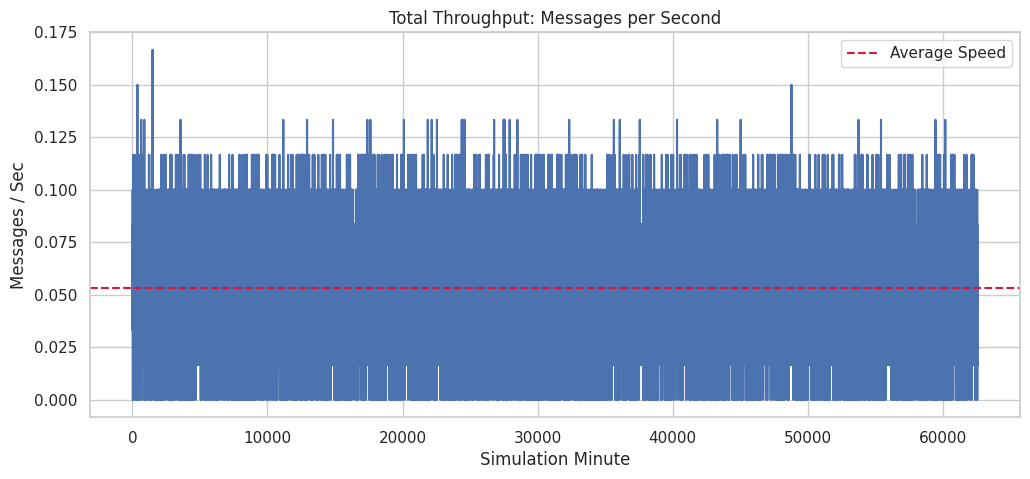

In [28]:
fig, ax = plt.subplots(figsize=(12, 5))
sns.lineplot(data=throughput_60s, x="window_minute", y="messages_per_second", ax=ax)
ax.axhline(overall_messages_per_second, color="crimson", linestyle="--", label="Average Speed")
ax.set_title("Total Throughput: Messages per Second")
ax.set_xlabel("Simulation Minute")
ax.set_ylabel("Messages / Sec")
ax.legend()
plt.show()

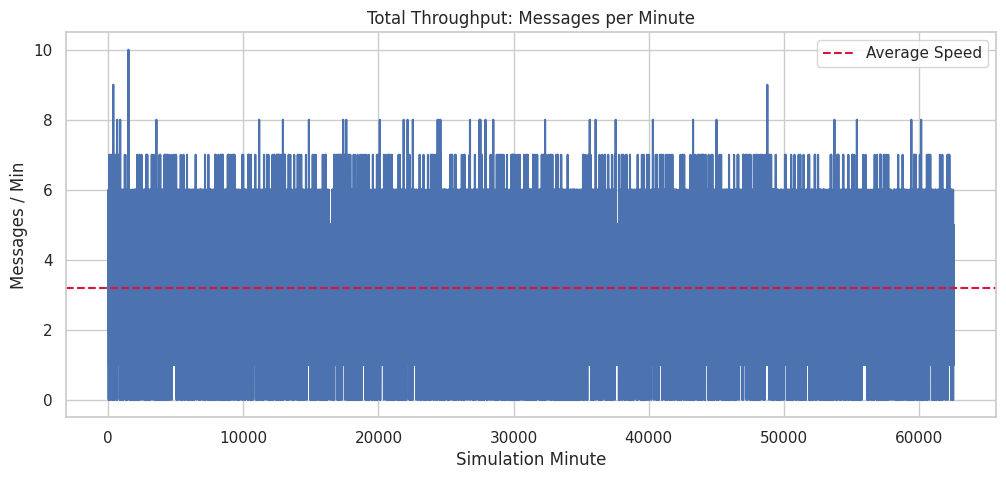

In [29]:
fig, ax = plt.subplots(figsize=(12, 5))
sns.lineplot(data=throughput_60s, x="window_minute", y="messages_per_minute", ax=ax)
ax.axhline(overall_messages_per_minute, color="crimson", linestyle="--", label="Average Speed")
ax.set_title("Total Throughput: Messages per Minute")
ax.set_xlabel("Simulation Minute")
ax.set_ylabel("Messages / Min")
ax.legend()
plt.show()

```markdown
## Throughput by Worker

Each line represents an individual worker. The aggregation window is also 60 seconds.
```

In [30]:
def build_worker_throughput(results: pd.DataFrame, bin_seconds: int = 60) -> pd.DataFrame:
    max_time = math.ceil(results["finish_time"].max())
    bins = np.arange(0, max_time + bin_seconds, bin_seconds)

    worker_throughput = (
        results.assign(time_bin=pd.cut(results["finish_time"], bins=bins, right=False, include_lowest=True))
        .groupby(["worker_id", "time_bin"], observed=False)
        .size()
        .rename("messages")
        .reset_index()
    )

    worker_throughput["window_start"] = worker_throughput["time_bin"].apply(lambda interval: interval.left).astype(float)
    worker_throughput["window_minute"] = worker_throughput["window_start"] / 60
    worker_throughput["messages_per_second"] = worker_throughput["messages"] / bin_seconds
    worker_throughput["messages_per_minute"] = worker_throughput["messages_per_second"] * 60
    return worker_throughput.drop(columns="time_bin")


worker_throughput_60s = build_worker_throughput(results, bin_seconds=60)
worker_throughput_60s.head()

,worker_id,messages,window_start,window_minute,messages_per_second,messages_per_minute
0,0,3,0.000,0.000,0.050,3.000
1,0,5,60.000,1.000,0.083,5.000
2,0,3,120.000,2.000,0.050,3.000
3,0,2,180.000,3.000,0.033,2.000
4,0,5,240.000,4.000,0.083,5.000


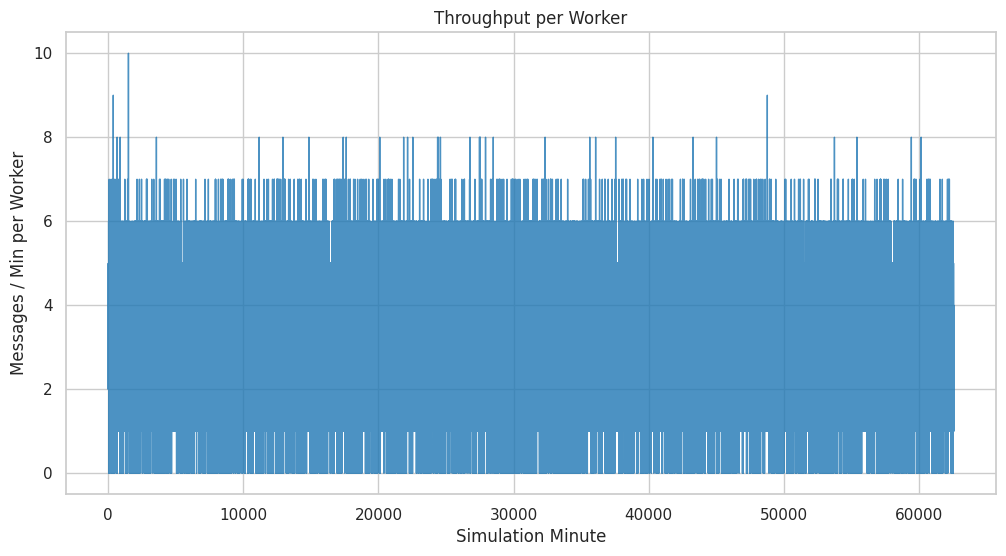

In [31]:
fig, ax = plt.subplots(figsize=(12, 6))
sns.lineplot(
    data=worker_throughput_60s,
    x="window_minute",
    y="messages_per_minute",
    hue="worker_id",
    palette="tab20",
    linewidth=1,
    alpha=0.8,
    legend=False,
    ax=ax,
)
ax.set_title("Throughput per Worker")
ax.set_xlabel("Simulation Minute")
ax.set_ylabel("Messages / Min per Worker")
plt.show()

```markdown
## Distribution of Worker Speeds and Processing Times
```

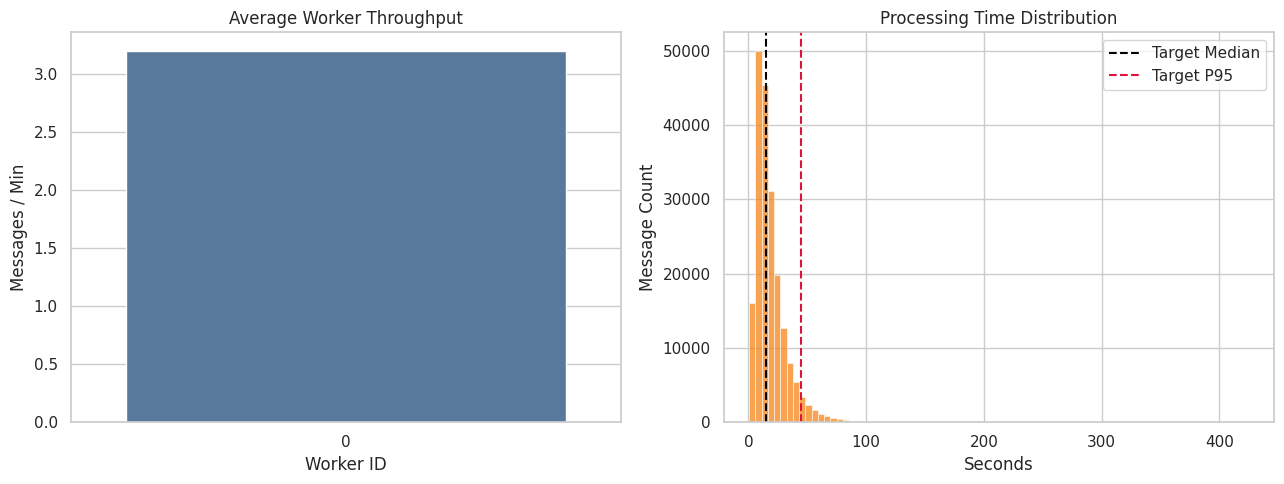

In [32]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

sns.barplot(
    data=worker_summary,
    x="worker_id",
    y="messages_per_minute_total_window",
    color="#4C78A8",
    ax=axes[0],
)
axes[0].set_title("Average Worker Throughput")
axes[0].set_xlabel("Worker ID")
axes[0].set_ylabel("Messages / Min")

sns.histplot(results["duration"], bins=80, color="#F58518", ax=axes[1])
axes[1].axvline(config.median_seconds, color="black", linestyle="--", label="Target Median")
axes[1].axvline(config.p95_seconds, color="crimson", linestyle="--", label="Target P95")
axes[1].set_title("Processing Time Distribution")
axes[1].set_xlabel("Seconds")
axes[1].set_ylabel("Message Count")
axes[1].legend()

plt.tight_layout()
plt.show()

```markdown
## Summary Text Output
```

In [33]:
print(f"Messages processed: {total_messages:,}")
print(f"Total processing time: {total_time_seconds:,.1f} sec = {total_time_minutes:,.1f} min = {total_time_hours:,.2f} h")
print(f"All workers: {overall_messages_per_second:.2f} msg/sec = {overall_messages_per_minute:.1f} msg/min")
print(
    "Single worker average: "
    f"{worker_summary['messages_per_second_total_window'].mean():.3f} msg/sec = "
    f"{worker_summary['messages_per_minute_total_window'].mean():.1f} msg/min"
)

Messages processed: 200,000
Total processing time: 3,755,185.6 sec = 62,586.4 min = 1,043.11 h
All workers: 0.05 msg/sec = 3.2 msg/min
Single worker average: 0.053 msg/sec = 3.2 msg/min
